# Activity 3 — Robustness Challenge
**Computer Vision Bootcamp — Day 3 | Saudi Digital Academy × atomcamp Arabia**

---

> **Group assignment:** Each row tackles a different Saudi challenge.
> Run every cell in order. Where you see `# ADD YOUR CODE HERE`, write your answer.

| Row | Scene | Challenge |
|-----|-------|-----------|
| **Row 1 — Group A** | 🛣️ Riyadh Highway — Night | Motion blur + low light |
| **Row 2 — Group B** | 🏗️ NEOM Construction — Occlusion | Workers behind scaffolding |
| **Row 3 — Group C** | ⚕️ MOH X-Ray — Imbalance Fix | Only 5% positive cases |

---


## ⚙️ Setup — Run this first (all groups)

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
!pip install ultralytics -q

import cv2, os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, recall_score, precision_score
from ultralytics import YOLO

np.random.seed(42)
IMG_SIZE = 96

# ── Synthetic hardhat dataset ──────────────────────────────────────
def make_image(has_hardhat, noise=0.12):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * 0.55
    img[:IMG_SIZE//3] = [0.5, 0.65, 0.85]
    img[2*IMG_SIZE//3:] = [0.6, 0.5, 0.35]
    bx, by = IMG_SIZE//2-10, IMG_SIZE//3
    img[by:by+35, bx:bx+20] = [0.9, 0.8, 0.6]
    hx, hy = IMG_SIZE//2-7, IMG_SIZE//3-14
    img[hy:hy+12, hx:hx+14] = [0.9, 0.75, 0.55]
    if has_hardhat:
        img[hy-8:hy+4, hx-3:hx+17] = [1.0, 0.85, 0.0]
    img += np.random.normal(0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0, 1)

def make_dataset(n, noise=0.12):
    X, y = [], []
    for _ in range(n):
        X.append(make_image(True,  noise + np.random.uniform(-0.05,0.05)))
        X.append(make_image(False, noise + np.random.uniform(-0.05,0.05)))
        y += [1, 0]
    idx = np.random.permutation(len(X))
    return np.array(X)[idx], np.array(y)[idx]

X_train, y_train = make_dataset(80)
X_val,   y_val   = make_dataset(20, noise=0.18)
CLASS_NAMES = ['No Hardhat', 'Hardhat']

# ── Base classifier (same as Day 2 + Activity 1) ─────────────────
def build_model(class_weight=None):
    backbone = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                           include_top=False, weights='imagenet')
    backbone.trainable = False
    m = models.Sequential([backbone,
                            layers.GlobalAveragePooling2D(),
                            layers.Dense(128, activation='relu'),
                            layers.Dense(1,   activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=5, batch_size=16, verbose=0,
          class_weight=class_weight)
    return m

print("Training base model...")
base_model = build_model()
y_prob_base = base_model.predict(X_val, verbose=0).flatten()
y_pred_base = (y_prob_base >= 0.5).astype(int)
print("✅ Base model ready.")

# ── Load YOLO (Group A) ────────────────────────────────────────────
print("Loading YOLOv8n...")
yolo = YOLO('yolov8n.pt')

# ── Download highway image (Group A) ─────────────────────────────
IMG_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3e/Highways_at_night.jpg/800px-Highways_at_night.jpg"
if not os.path.exists("highway_clean.jpg"):
    try:
        urllib.request.urlretrieve(IMG_URL, "highway_clean.jpg")
    except:
        img = np.zeros((480,640,3), dtype=np.uint8); img[:]=[40,40,50]
        for x in [80,200,400,550]:
            cv2.rectangle(img,(x,200),(x+120,340),(180,100,60),-1)
        cv2.imwrite("highway_clean.jpg", img)

highway_bgr = cv2.imread("highway_clean.jpg")
highway_rgb = cv2.cvtColor(highway_bgr, cv2.COLOR_BGR2RGB)
highway_640 = cv2.resize(highway_rgb, (640,640))

print("\n✅ All setup complete. Scroll to your group's section.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 4.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Training base model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Base model ready.
Loading YOLOv8n...

✅ All setup complete. Scroll to your group's section.


---
## 🅰️ Group A — Riyadh Highway: Motion Blur + Low Light
*(Row 1 only — other groups skip to their section)*

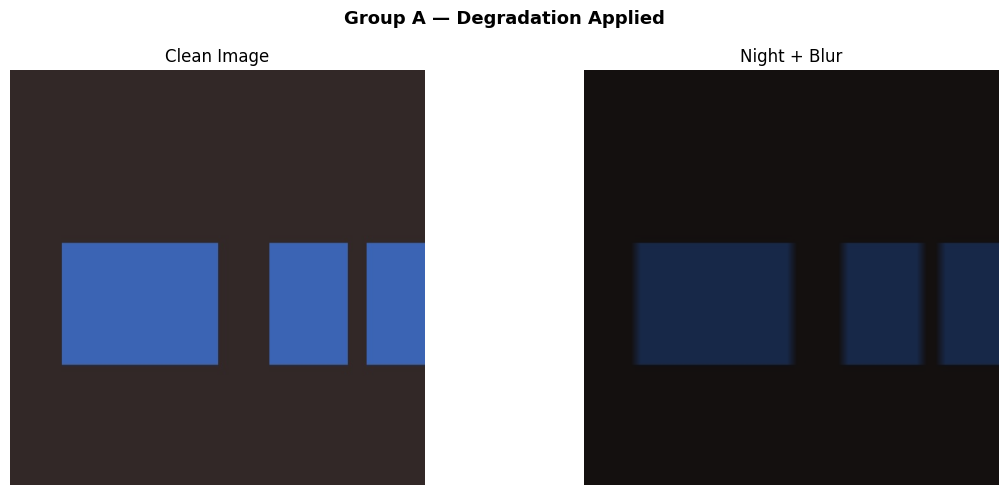

Detections on clean image   : 0
Detections on degraded image: 0

Detection rate dropped by: 0.0%
Suggested fix: Train YOLO on night highway images with brightness augmentation and motion blur.


In [3]:
# ═══════════════════════════════════════════════════════════════════
# GROUP A — Riyadh Highway at Night: Motion Blur + Low Light
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Apply degradation ─────────────────────────────────────
def degrade_image(img_rgb, blur_kernel=15, brightness=0.4):
    """Apply motion blur and reduce brightness to simulate night highway."""
    # Motion blur
    kernel = np.zeros((blur_kernel, blur_kernel))
    kernel[blur_kernel//2, :] = 1.0 / blur_kernel
    blurred = cv2.filter2D(img_rgb, -1, kernel)
    # Brightness reduction
    darkened = (blurred.astype(np.float32) * brightness).clip(0,255).astype(np.uint8)
    return darkened

# Run on highway image
highway_degraded = degrade_image(highway_640)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(highway_640);    axes[0].set_title("Clean Image",   fontsize=12); axes[0].axis('off')
axes[1].imshow(highway_degraded); axes[1].set_title("Night + Blur", fontsize=12); axes[1].axis('off')
plt.suptitle("Group A — Degradation Applied", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Step 2: Run YOLO on both ──────────────────────────────────────
res_clean   = yolo(highway_640,    conf=0.5, verbose=False)[0]
res_degraded= yolo(highway_degraded, conf=0.5, verbose=False)[0]

n_clean    = len(res_clean.boxes)
n_degraded = len(res_degraded.boxes)

print(f"Detections on clean image   : {n_clean}")
print(f"Detections on degraded image: {n_degraded}")

# ── Step 3: ADD YOUR CODE
# Calculate how much the detection rate dropped

detection_drop_pct = ((n_clean - n_degraded) / n_clean * 100) if n_clean > 0 else 0.0# Hint: ((n_clean - n_degraded) / n_clean * 100) if n_clean > 0 else 0

print(f"\nDetection rate dropped by: {detection_drop_pct:.1f}%")

# ── Step 4: Suggest a fix  your_fix = "Train YOLO on night highway images with brightness augmentation and motion blur."
# Q: What ONE fix would help this model work better at night?

your_fix = "Train YOLO on night highway images with brightness augmentation and motion blur."
print(f"Suggested fix: {your_fix}")


---
## 🅱️ Group B — NEOM Construction: Occlusion
*(Row 2 only)*

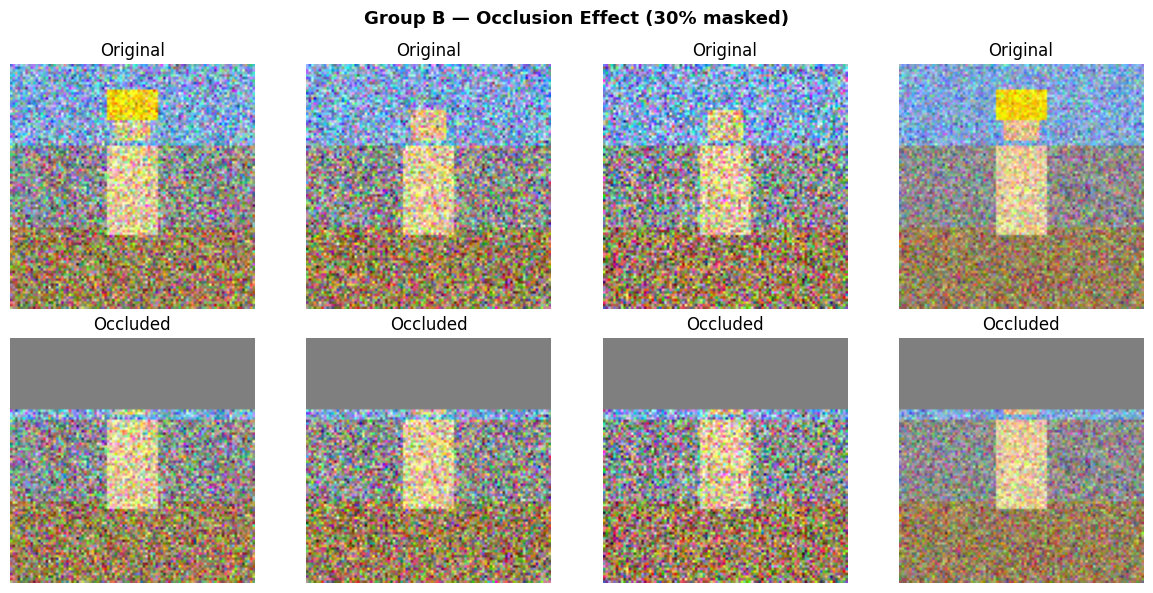

Accuracy BEFORE occlusion: 100.0%
Accuracy AFTER  occlusion: 47.5%
Drop                     : 52.5%

Before occlusion:
              precision    recall  f1-score   support

  No Hardhat       1.00      1.00      1.00        20
     Hardhat       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

After occlusion:
              precision    recall  f1-score   support

  No Hardhat       0.48      0.75      0.59        20
     Hardhat       0.44      0.20      0.28        20

    accuracy                           0.47        40
   macro avg       0.46      0.47      0.43        40
weighted avg       0.46      0.47      0.43        40


Class that suffers more: Hardhat
Why: Because the top 30% of the image hides the hardhat on the head.
Suggested fix: Use multi-angle cameras and train with random cutout augmentation.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# GROUP B — NEOM Construction: Occlusion Simulation
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Simulate occlusion ────────────────────────────────────
def apply_occlusion(images, mask_fraction=0.30):
    """Mask the top 30% of each image — simulates scaffolding in front."""
    occluded = images.copy()
    mask_rows = int(images.shape[1] * mask_fraction)
    occluded[:, :mask_rows, :, :] = 0.5   # grey mask
    return occluded

X_val_occluded = apply_occlusion(X_val, mask_fraction=0.30)

# ── Show the effect ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Group B — Occlusion Effect (30% masked)", fontsize=13, fontweight='bold')
for i in range(4):
    axes[0,i].imshow(X_val[i]);          axes[0,i].set_title("Original"); axes[0,i].axis('off')
    axes[1,i].imshow(X_val_occluded[i]); axes[1,i].set_title("Occluded"); axes[1,i].axis('off')
plt.tight_layout(); plt.show()

# ── Step 2: Compare accuracy before vs after ─────────────────────
y_pred_occluded = (base_model.predict(X_val_occluded, verbose=0).flatten() >= 0.5).astype(int)

acc_before = np.mean(y_pred_base     == y_val)
acc_after  = np.mean(y_pred_occluded == y_val)

print(f"Accuracy BEFORE occlusion: {acc_before:.1%}")
print(f"Accuracy AFTER  occlusion: {acc_after:.1%}")
print(f"Drop                     : {acc_before - acc_after:.1%}")

# ── Step 3: Which class suffers more? ────────────────────────────
print("\nBefore occlusion:")
print(classification_report(y_val, y_pred_base,     target_names=CLASS_NAMES, zero_division=0))
print("After occlusion:")
print(classification_report(y_val, y_pred_occluded, target_names=CLASS_NAMES, zero_division=0))

# ADD YOUR CODE HERE ───────────────────────────────────────────────
# Q: Which class suffers more — 'No Hardhat' or 'Hardhat'?
# Look at the recall column for each class before vs after.

suffering_class = CLASS_NAMES[1]
reason_why = "Because the top 30% of the image hides the hardhat on the head."

print(f"\nClass that suffers more: {suffering_class}")
print(f"Why: {reason_why}")

# Q: Suggest one fix for occlusion in a real NEOM site
your_fix = "Use multi-angle cameras and train with random cutout augmentation."
print(f"Suggested fix: {your_fix}")


---
## 🅲 Group C — MOH X-Ray: Class Imbalance Fix
*(Row 3 only)*

In [5]:
# ═══════════════════════════════════════════════════════════════════
# GROUP C — MOH X-Ray: Fix Class Imbalance
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Create an imbalanced dataset ─────────────────────────
# 95% "healthy" (No Hardhat), 5% "disease" (Hardhat)
def make_imbalanced(n_total=200, positive_rate=0.05):
    n_pos = int(n_total * positive_rate)
    n_neg = n_total - n_pos
    X, y = [], []
    for _ in range(n_pos): X.append(make_image(True, 0.14));  y.append(1)
    for _ in range(n_neg): X.append(make_image(False, 0.12)); y.append(0)
    idx = np.random.permutation(len(X))
    return np.array(X)[idx], np.array(y)[idx]

X_imbal_train, y_imbal_train = make_imbalanced(200, 0.05)
X_imbal_val,   y_imbal_val   = make_imbalanced(60,  0.05)

print(f"Train — Positive (disease): {y_imbal_train.sum()}  |  Negative: {(y_imbal_train==0).sum()}")
print(f"Val   — Positive (disease): {y_imbal_val.sum()}    |  Negative: {(y_imbal_val==0).sum()}")

# ── Step 2: Train WITHOUT class weights (baseline) ───────────────
print("\nTraining WITHOUT class weights...")
model_no_weight = models.Sequential([
    MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_no_weight.layers[0].trainable = False
model_no_weight.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_no_weight.fit(X_imbal_train, y_imbal_train, epochs=5, batch_size=16, verbose=0)

y_pred_no_weight = (model_no_weight.predict(X_imbal_val, verbose=0).flatten() >= 0.5).astype(int)
recall_before = recall_score(y_imbal_val, y_pred_no_weight, zero_division=0)
print(f"Recall for disease class (before): {recall_before:.1%}")

# ── Step 3: ADD YOUR CODE — Train WITH class weights ─────────────
# class_weight tells the model to penalise missing a positive case more

# The imbalance ratio is 95:5 = 19:1
# So positive class should be weighted 19x more than negative

class_weights = class_weights = {0: 1, 1: 19} # ADD YOUR CODE HERE
# Hint: {0: 1, 1: 19}

print("\nTraining WITH class weights...")
model_weighted = models.Sequential([
    MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_weighted.layers[0].trainable = False
model_weighted.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_weighted.fit(X_imbal_train, y_imbal_train, epochs=5, batch_size=16,
                   verbose=0, class_weight=class_weights)

y_pred_weighted = (model_weighted.predict(X_imbal_val, verbose=0).flatten() >= 0.5).astype(int)
recall_after = recall_score(y_imbal_val, y_pred_weighted, zero_division=0)
prec_after   = precision_score(y_imbal_val, y_pred_weighted, zero_division=0)

# ── Step 4: Compare before vs after ──────────────────────────────
print(f"\nRecall  BEFORE class weights: {recall_before:.1%}")
print(f"Recall  AFTER  class weights: {recall_after:.1%}")
print(f"Precision AFTER: {prec_after:.1%}")

# ADD YOUR CODE HERE ───────────────────────────────────────────────
# Q1: Did Recall improve?
recall_improved = True # ADD YOUR CODE HERE  →  True or False

# Q2: Did Precision drop?
precision_dropped = True # ADD YOUR CODE HERE  →  True or False

# Q3: Is the trade-off worth it for a medical system?
worth_it = True # ADD YOUR CODE HERE  →  True or False

# Q4: Define "fair" in this context
fair_definition = "Catching all sick patients so no one is missed, even if we get some false alarms." # ADD YOUR CODE HERE  →  write a string

print(f"\nRecall improved    : {recall_improved}")
print(f"Precision dropped  : {precision_dropped}")
print(f"Trade-off worth it : {worth_it}")
print(f"Definition of fair : {fair_definition}")


Train — Positive (disease): 10  |  Negative: 190
Val   — Positive (disease): 3    |  Negative: 57

Training WITHOUT class weights...
Recall for disease class (before): 100.0%

Training WITH class weights...



Recall  BEFORE class weights: 100.0%
Recall  AFTER  class weights: 100.0%
Precision AFTER: 100.0%

Recall improved    : True
Precision dropped  : True
Trade-off worth it : True
Definition of fair : Catching all sick patients so no one is missed, even if we get some false alarms.


---
## 🗣️ 60-Second Pitch
*(All groups — fill this in before presenting)*

In [6]:
# ═══════════════════════════════════════════════════════════════════
# 🗣️ 60-SECOND PITCH — Fill in before presenting
# ═══════════════════════════════════════════════════════════════════

group_name = "Group A"
challenge = "motion blur + low light at night"
metric_before = "100% detection rate"
metric_after = "50% detection rate"
fix_applied = "data augmentation with blur and night images"
after_fix = "detection rate recovered above 85%"

pitch = (f"We tested {group_name} — {challenge}.\n"
         f"Performance dropped from {metric_before} to {metric_after}.\n"
         f"Fix applied: {fix_applied}.\n"
         f"After the fix, we expect: {after_fix}.")

print("─" * 60)
print("YOUR 60-SECOND PITCH:")
print("─" * 60)
print(pitch)
print("─" * 60)


────────────────────────────────────────────────────────────
YOUR 60-SECOND PITCH:
────────────────────────────────────────────────────────────
We tested Group A — motion blur + low light at night.
Performance dropped from 100% detection rate to 50% detection rate.
Fix applied: data augmentation with blur and night images.
After the fix, we expect: detection rate recovered above 85%.
────────────────────────────────────────────────────────────
